# Recinos Dispersion Plots

In [23]:
import pandas as pd

In [24]:
OHCO = "parte capit sent token".split()
TOKEN = pd.read_csv("recinos-TOKEN.csv").set_index(OHCO)

In [25]:
# TOKEN.head()

# By Chapter

In [26]:
CAPIT = TOKEN.groupby(['parte','capit','term_str']).term_str.count().to_frame()
CAPITM = CAPIT.unstack(fill_value=0)
CAPITM.columns = CAPITM.columns.droplevel(0)
CAPITM = CAPITM / CAPITM.sum()
CAPITM['CHAP'] = [':'.join(map(str,val)) for val in CAPITM.index.values]
CAPITM = CAPITM.reset_index(drop=True).set_index('CHAP')

In [27]:
def plot_char(*char_name):
    title = ", ".join(char_name)
    legend = len(char_name) == 2
    if len(char_name) > 1:
        corr = CAPITM[list(char_name)].corr('kendall').iloc[0,1]
        title += f" (r = {round(corr, 2)})"
    CAPITM[list(char_name)].plot.bar(figsize=(10,2), rot=90, title=title, legend=legend); 

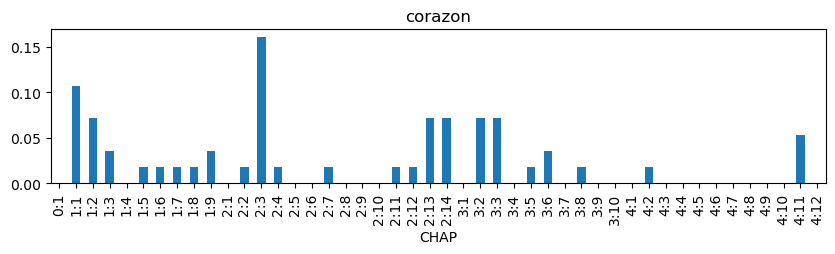

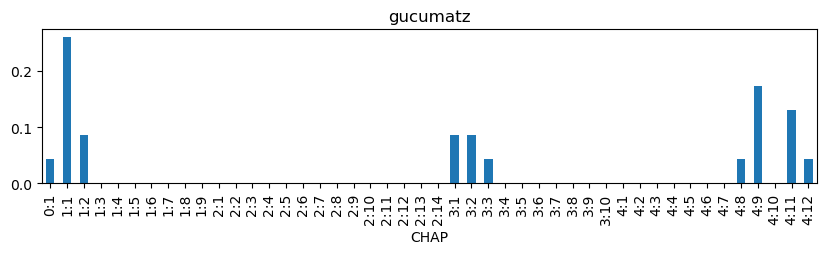

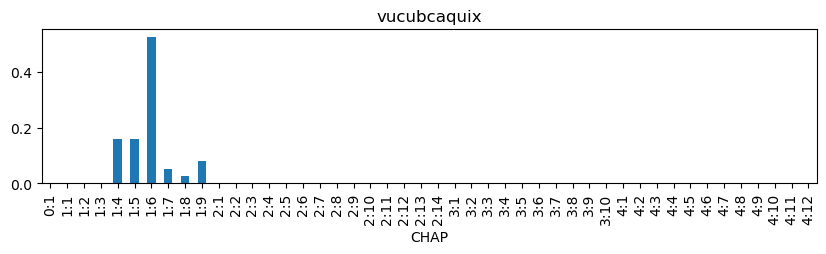

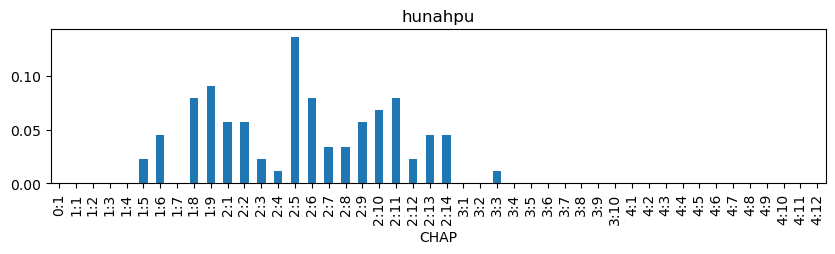

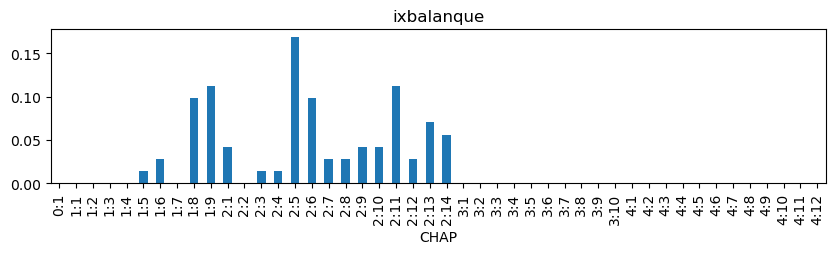

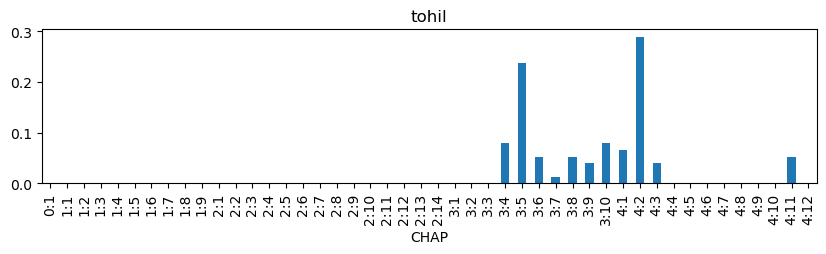

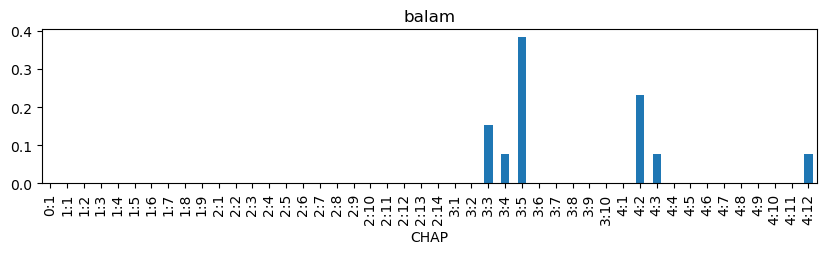

In [35]:
for name in "corazon gucumatz vucubcaquix hunahpu ixbalanque tohil balam".split():
    plot_char(name.lower())

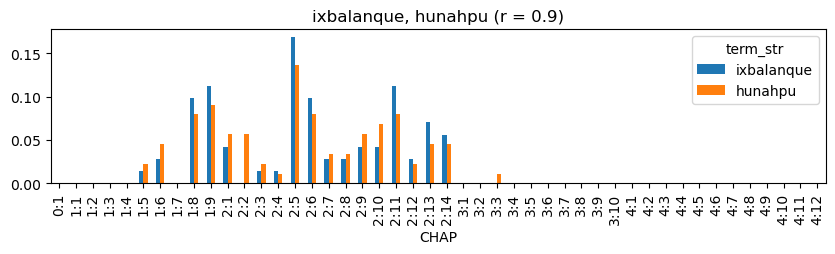

In [29]:
plot_char('ixbalanque', 'hunahpu')

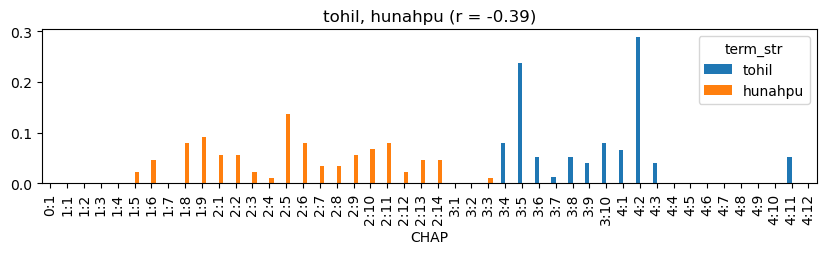

In [30]:
plot_char('tohil', 'hunahpu')

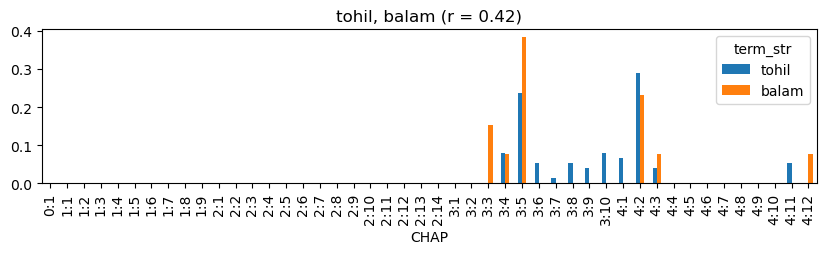

In [31]:
plot_char('tohil', 'balam')

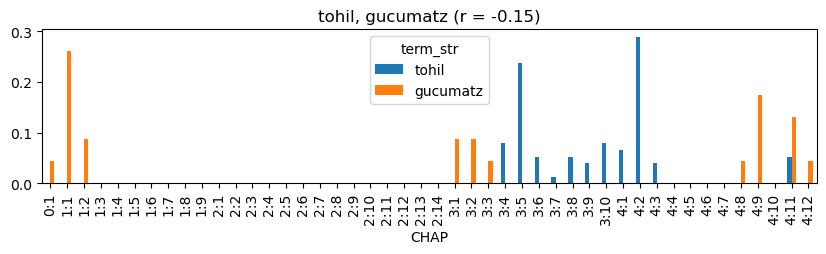

In [32]:
plot_char('tohil', 'gucumatz')

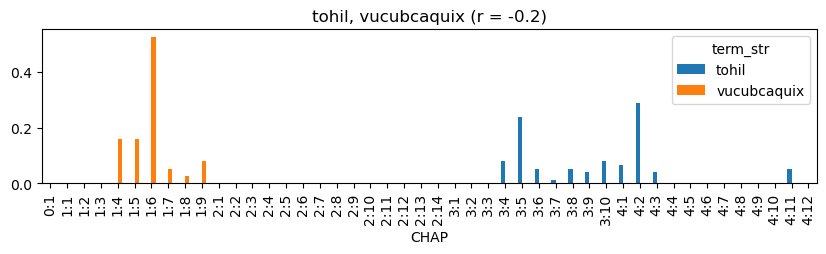

In [33]:
plot_char('tohil', 'vucubcaquix')

# By Chunk

In [13]:
chunks = 50
TOKEN['raw_count'] = range(len(TOKEN))
TOKEN['chunk'] = pd.cut(TOKEN.raw_count, chunks, labels=range(chunks))

In [14]:
M = TOKEN.groupby(['chunk','term_str'], observed=False).term_str.count().unstack(fill_value=0).reset_index(drop=True)
M.index.name = 'chunk'
M = M / M.sum()

In [15]:
def pair_corr(a, b, method='kendall'):
    return M[[a,b]].corr(method=method).values[0,1].round(2)

def plot_cooc(a, b):
    my_corr = pair_corr(a,b)
    M[[a,b]].rolling(10).mean().plot.bar(figsize=(10,2), style='o-', title=f"{a}, {b} {my_corr}");

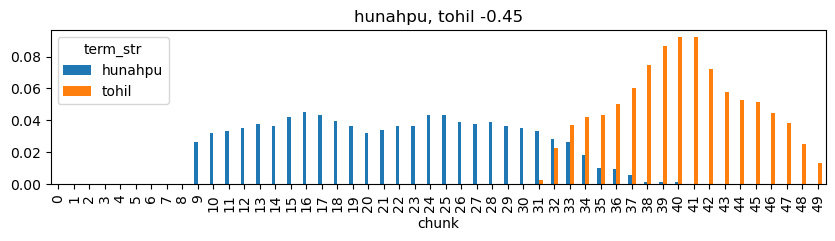

In [16]:
plot_cooc('hunahpu', 'tohil')

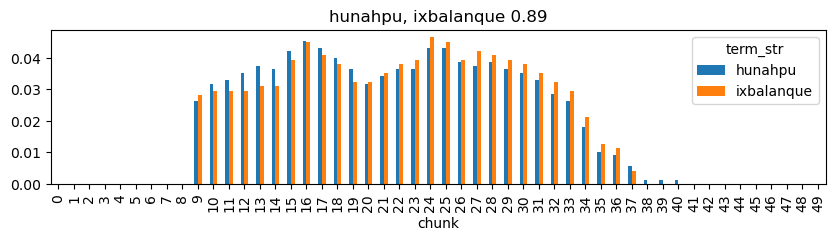

In [17]:
plot_cooc('hunahpu', 'ixbalanque')

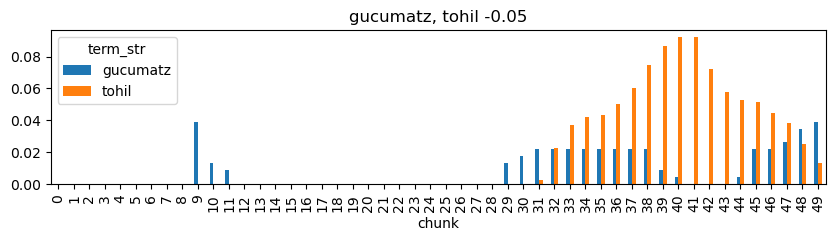

In [18]:
plot_cooc('gucumatz', 'tohil')

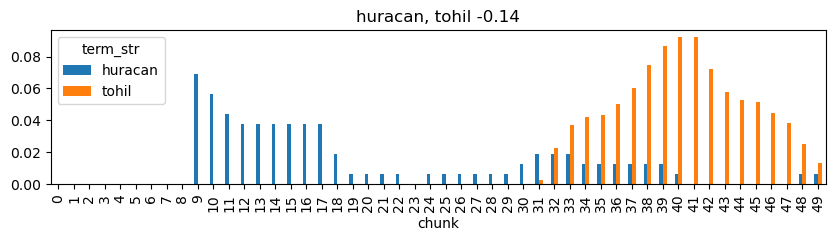

In [19]:
plot_cooc('huracan', 'tohil')

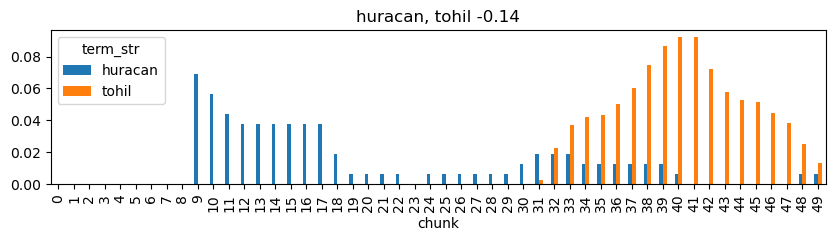

In [20]:
plot_cooc('huracan', 'tohil')

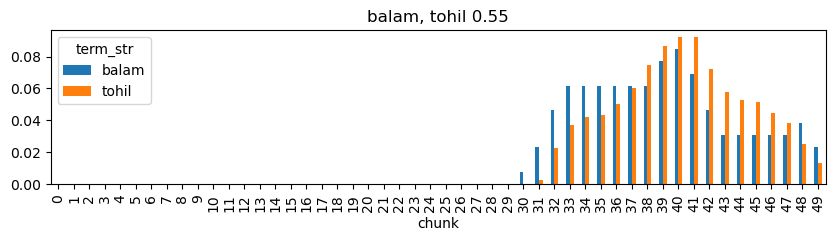

In [21]:
plot_cooc('balam', 'tohil')

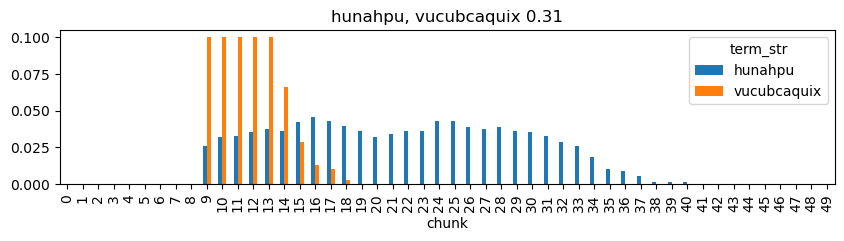

In [22]:
plot_cooc('hunahpu', 'vucubcaquix')